In [1]:
import fargopy as fp
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

%load_ext autoreload
%autoreload 2

Running FARGOpy version 0.3.15


In [2]:
sim = fp.Simulation(output_dir='/home/jupitergeci/fargowork/data/fargo_data')

Your simulation is now connected with '/home/jupitergeci/fargo3d/'
Now you are connected with output directory '/home/jupitergeci/fargowork/data/fargo_data'
Found a variables.par file in '/home/jupitergeci/fargowork/data/fargo_data', loading properties
Loading variables
93 variables loaded
Simulation in 3 dimensions
Loading domain in spherical coordinates:
	Variable phi: 256 [[0, -1.564660403643354], [-1, 1.564660403643354]]
	Variable r: 128 [[0, 0.50390625], [-1, 1.49609375]]
	Variable theta: 32 [[0, 1.44319539835739], [-1, 1.5687709152323963]]
Number of snapshots in output directory: 216
Planets found in summary.dat:
  Name: jupiter, Distance: 1.0, Mass: 0.001
Configuration variables and domains load into the object. See e.g. <sim>.vars


In [3]:
gasdens=sim.load_field('gasdens',slice='phi=0',snapshot=60,interpolate=True)

Loading 2D density data for slice: phi=0.


In [5]:
xs=gasdens.df.var1_mesh[0]
zs=gasdens.df.var2_mesh[0]

dens=gasdens.df.gasdens_mesh[0]


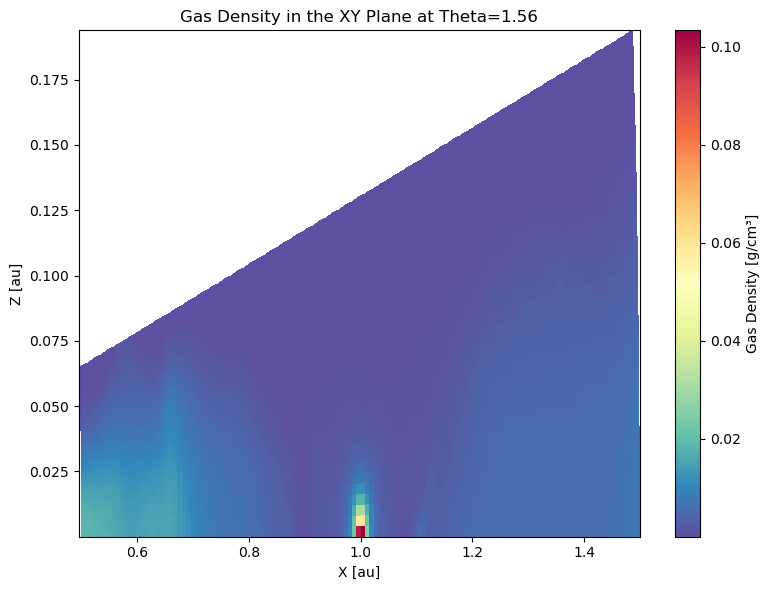

In [6]:
plt.figure(figsize=(8, 6))
plt.pcolormesh(xs, zs, dens, cmap='Spectral_r')
plt.colorbar(label='Gas Density [g/cm³]')
plt.xlabel('X [au]')
plt.ylabel('Z [au]')
plt.title('Gas Density in the XY Plane at Theta=1.56')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import plotly.graph_objects as go

# ----- 1. PREPARACIÓN DE DATOS -----

# Aplanar los datos
x_flat = xs.flatten().reshape(-1, 1)
z_flat = zs.flatten().reshape(-1, 1)
XZ_input = np.hstack((x_flat, z_flat))   # Shape: (4096, 2)
dens_flat = dens.flatten().reshape(-1, 1)  # Shape: (4096, 1)

# ----- 2. RED NEURONAL -----
class Net2D(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

# Preparar datos para PyTorch
X_tensor = torch.tensor(XZ_input, dtype=torch.float32)
y_tensor = torch.tensor(dens_flat, dtype=torch.float32)
dataset = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(dataset, batch_size=128, shuffle=True)

# Inicializar red, pérdida y optimizador
model = Net2D()
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ----- 3. ENTRENAMIENTO -----
for epoch in range(10000):
    for batch_x, batch_y in loader:
        pred = model(batch_x)
        loss = loss_fn(pred, batch_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4e}")

# ----- 4. PREDICCIÓN Y VISUALIZACIÓN -----
with torch.no_grad():
    y_pred = model(X_tensor).numpy()



Epoch 0, Loss: 1.2154e-04
Epoch 50, Loss: 1.5627e-06
Epoch 100, Loss: 6.5014e-05
Epoch 150, Loss: 8.3178e-07
Epoch 200, Loss: 1.2894e-05
Epoch 250, Loss: 1.5000e-06
Epoch 300, Loss: 2.0777e-06
Epoch 350, Loss: 1.9080e-05
Epoch 400, Loss: 2.4216e-05
Epoch 450, Loss: 1.8983e-05
Epoch 500, Loss: 1.6610e-06
Epoch 550, Loss: 2.1668e-07
Epoch 600, Loss: 2.9694e-06
Epoch 650, Loss: 1.4406e-06
Epoch 700, Loss: 6.8520e-07
Epoch 750, Loss: 4.9927e-05
Epoch 800, Loss: 5.2408e-05
Epoch 850, Loss: 2.9457e-06
Epoch 900, Loss: 5.1113e-07
Epoch 950, Loss: 4.1158e-05
Epoch 1000, Loss: 3.1145e-06
Epoch 1050, Loss: 6.6865e-07
Epoch 1100, Loss: 8.4024e-07
Epoch 1150, Loss: 3.3586e-07
Epoch 1200, Loss: 3.3182e-07
Epoch 1250, Loss: 7.3843e-07
Epoch 1300, Loss: 1.1279e-06
Epoch 1350, Loss: 1.3564e-06
Epoch 1400, Loss: 2.1485e-07
Epoch 1450, Loss: 1.8354e-06
Epoch 1500, Loss: 6.0446e-06
Epoch 1550, Loss: 1.9315e-06
Epoch 1600, Loss: 2.5992e-07
Epoch 1650, Loss: 2.9181e-07
Epoch 1700, Loss: 1.1412e-06
Epoch 17

In [ ]:
import plotly.graph_objects as go
# Convertir a 2D para graficar
x2d = xs
z2d = zs
true_dens = dens
pred_dens = y_pred.reshape(xs.shape)
# Visualización con heatmap
fig = go.Figure()


fig.add_trace(go.Heatmap(
    z=true_dens,
    x=x2d[0],  # Eje X (suponiendo que x es constante por filas)
    y=z2d[:,0],  # Eje Z (suponiendo que z es constante por columnas)
    colorscale='Spectral_r',
    colorbar_title='Densidad',
    name='Real',
    zsmooth='best'
))

fig.add_trace(go.Heatmap(
    z=pred_dens,
    x=x2d[0],
    y=z2d[:,0],
    colorscale='Spectral_r',
    showscale=False,
    name='Predicho',
    zsmooth='best',
    visible=False
))

fig.update_layout(
    updatemenus=[
        dict(
            type='buttons',
            buttons=[
                dict(label='Densidad Real',
                     method='update',
                     args=[{'visible': [True, False]}]),
                dict(label='Densidad Predicha',
                     method='update',
                     args=[{'visible': [False, True]}])
            ],
            direction='left',
            showactive=True,
            x=0.5,
            y=1.15,
            xanchor='center',
            yanchor='top'
        )
    ],
    title='Interpolación con Red Neuronal en el Plano XZ',
    xaxis_title='X',
    yaxis_title='Z',
    height=600
)

fig.show()